## 0. Define MDP environment: Cliff Walk


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

""" Tile layout (36=start, 47=goal, 37-46=cliff)
0	1	2	3	4	5	6	7	8	9	10	11
12	13	14	15	16	17	18	19	20	21	22	23
24	25	26	27	28	29	30	31	32	33	34	35
36	37	38	39	40	41	42	43	44	45	46	47
"""

cliff_states = np.arange(37, 47)  # States for cliff tiles
goal_state = 47 # Goal state

# def get_reward(state: int, cliff_pos: np.array, goal_pos: int) -> int:
def get_reward(state): #when arriving at state
    """
    Compute reward for given state
    """
    if state == goal_state:       # Reward of +100 for reaching goal
        return 100
    elif state in cliff_states:    # Reward of -100 for falling down cliff
        return -100
    else:                       # Otherwise, reward of -1 for each move
        return -1



def get_state(agent_pos):
    """
    (x,y)-position -> state integer in [0,47]
    """
    return 12 * agent_pos[0] + agent_pos[1]


def get_position(state):
    """
    state integer in [0,47] -> (x,y)-position
    """
    return (int(np.floor(state / 12)), state % 12)



def move_agent(agent_pos, action):
    """
    Move agent to new position based on current position and action
    """
    # Retrieve agent position
    (pos_x, pos_y) = agent_pos

    if action == 0:  # Up
        pos_x = pos_x - 1 if pos_x > 0 else pos_x
    elif action == 1:  # Down
        pos_x = pos_x + 1 if pos_x < 3 else pos_x
    elif action == 2:  # Left
        pos_y = pos_y - 1 if pos_y > 0 else pos_y
    elif action == 3:  # Right
        pos_y = pos_y + 1 if pos_y < 11 else pos_y
    else:  # Infeasible move
        raise Exception("Infeasible move")

    agent_pos = (pos_x, pos_y)

    return agent_pos


def get_Q_from_V(V_table, gamma):
    """
    Given V_table, output Q_table of size (4,48)

    """
    Q_table = np.zeros((4, 48))

    for state in range(37): 
        for action in range(4):
            pos = get_position(state)
            pos_next = move_agent(pos, action)
            state_next = get_state(pos_next)
            r = get_reward(state_next)
            Q_table[action, state] = r + gamma * V_table[state_next] # Q (a, s) = r + gamma * V(s')
    
    return Q_table


def visualize_value_function(V, title="Value Function"):
    """
    Visualizes the value function as a heatmap.
    V should be a vector of length 48.
    """
    V_grid = V.reshape((4,12))
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(V_grid, annot=True, fmt=".1f", cmap="viridis",
                     cbar=True, square=True, xticklabels=False, yticklabels=False)
    ax.set_title(title)
    plt.show()

def visualize_policy(policy, title="Policy (Greedy)"):
    """
    Visualizes the policy as arrows on the grid.
    The policy is assumed to be of shape (4,37) for nonterminal states.
    Terminal states (37-47) are left blank.
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(np.zeros((4,12)), cmap="Greys", vmin=0, vmax=1)
    action_arrows = {0: '↑', 1: '↓', 2: '←', 3: '→'}
    for state in range(37):
        pos = get_position(state)
        best_action = np.argmax(policy[:,state])
        arrow = action_arrows[best_action]
        ax.text(pos[1], pos[0], arrow, ha="center", va="center", color="red", fontsize=16)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

## 1. MC Policy evaluation of $V^\pi$ for a given policy $ \pi$

We start with the tabular Monte Carlo (MC) policy evaluation. (No neural network. $V^\pi(s)$ value estimated saparately for eah $s\in \mathcal{S}$.) The following code considers the uniform random action policy for the policy $\pi$.


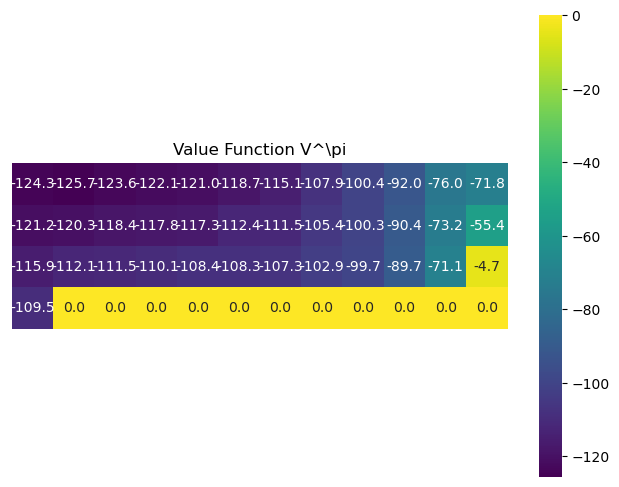

In [14]:
V_table = np.zeros(48)
gamma = 1.0
N = 1024


#Perform MC Policy Evaluation
for starting_state in range(37):
# range(37) contains non-terminal states
    for _ in range(N):
        reward_cache = []
        agent_pos = get_position(starting_state)
        game_over = False # game_over flag
        while True: #Simulate episode
            action = np.random.randint(4) #random action policy
            agent_pos = move_agent(agent_pos, action)
            state = get_state(agent_pos)
            reward_cache.append(get_reward(state))
            #End episode if game over
            if (state == goal_state or state in cliff_states):
                break
        # update value function
        V_table[starting_state] += sum(gamma**k * r for k, r in enumerate(reward_cache))
    V_table[starting_state] /= N

    
# print(V_table.reshape(4,-1))
visualize_value_function(V_table, 'Value Function V^\pi')

## 2. Estimate $V^\star$ and $\pi^\star$ via Value Iteration

Next, we implement Value Iteration:
\begin{align*}
V^{k+1} = \max_{a \in \mathcal{A}} \mathbb{E}_{(r,s')\sim p(\cdot,\cdot|s,a)} [r + \gamma V^k (s') | s, a]
\end{align*}

and obtain the greedy policy:
\begin{align*}
\pi^{k+1}(s) = \text{argmax}_{a \in \mathcal{A}} \mathbb{E}_{(r,s')\sim p(\cdot,\cdot|s,a)} [r + \gamma V^k (s') | s, a].
\end{align*}


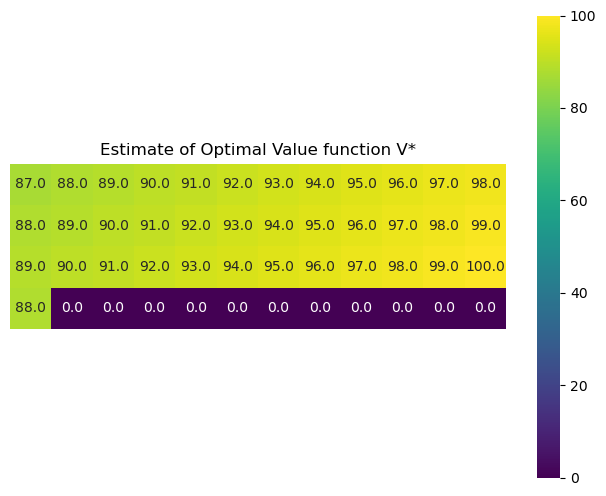

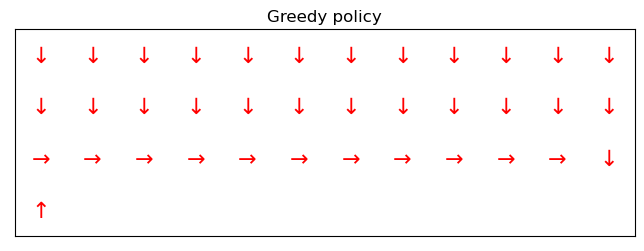

In [68]:
num_iterations = 20
gamma = 1.0


V_table = np.zeros(48) # inititalize v table.

#Perform Value Iteration
for itr in range(num_iterations):

    V_table_prev = V_table.copy()

    # Update value function for all states
    for state in range(37): #range(37) are non-terminal states
        candidates = []
        for action in range(4):
            pos = get_position(state)
            pos_next = move_agent(pos, action)
            state_next = get_state(pos_next)
            r = get_reward(state_next)
            new_value = r + gamma * V_table_prev[state_next]
            candidates.append(new_value)
        V_table[state] = max(candidates)
        
visualize_value_function(V_table, 'Estimate of Optimal Value function V*')


#Compute greedy policy from V
Q_table = get_Q_from_V(V_table, gamma)
# get policy based off the value function
pi = np.zeros((4,37))
for state in range(37):
    pi[np.argmax(Q_table[:,state]), state] = 1
visualize_policy(pi, "Greedy policy")

## 3. Policy Evaluation using Linear Algebra

Next, we use linear algebra (matrix inverse) to carry out policy evaluation exactly. This approach works in the tabular setting when the size of the state space is small. Consider the tabular setting where $|\mathcal{S}|, |\mathcal{A}| < \infty$, and a policy $\pi$ is given.

The key idea is to directly solve the Bellman equation:
\begin{align*}
V_{\pi}(s) &= \underset{\substack{a \sim \pi(a|s) \\ (r,s')\sim p(\cdot,\cdot|s,a)}}{\mathbb{E}} [r + \gamma V_{\pi} (s') | s]\\
&= \sum_a \pi(a|s) \sum_{s', r} p(s', r \mid s, a)[r + \gamma V_\pi(s')] \\
&= \sum_a \pi(a|s) \sum_{s', r} r \cdot p(s', r \mid s, a) + \sum_a \pi(a|s) \sum_{s', r} p(s', r \mid s, a) \gamma V_\pi(s') \\
&= \sum_a \pi(a|s) r(s, a) + \gamma \sum_{s'} \left\{ \sum_a \pi(a|s) \cdot p(s' \mid s, a) \right\} V_\pi(s') \\
&= r_\pi(s) + \gamma \sum_{s'} P_\pi(s' \mid s) V_\pi(s'),
\end{align*}
where $r(s,a)$ is the deterministic reward (for the Cliff Walk environment) given state $s$ and action $a$ and $V_\pi \in \mathbb{R}^{|\mathcal{S}|}, r_\pi \in \mathbb{R}^{|\mathcal{S}|}, P_\pi \in \mathbb{R}^{|\mathcal{S}| \times |\mathcal{S}|}$ are defined as:


\begin{align*}
V_\pi &= 
\begin{bmatrix}
V_\pi(s_1) \\
V_\pi(s_2) \\
\vdots \\
V_\pi(s_n)
\end{bmatrix} \\
r_\pi &= 
\begin{bmatrix}
r_\pi(s_1) \\
r_\pi(s_2) \\
\vdots \\
r_\pi(s_n)
\end{bmatrix}
=
\begin{bmatrix}
\sum_a \pi(a|s_1) r(s_1, a) \\
\sum_a \pi(a|s_2) r(s_2, a) \\
\vdots \\
\sum_a \pi(a|s_n) r(s_n, a)
\end{bmatrix} \\
P_\pi &=
\begin{bmatrix}
P_\pi(s_1|s_1) & P_\pi(s_2|s_1) & \cdots & P_\pi(s_n|s_1) \\
P_\pi(s_1|s_2) & P_\pi(s_2|s_2) & \cdots & P_\pi(s_n|s_2) \\
\vdots & \vdots & \ddots & \vdots \\
P_\pi(s_1|s_n) & P_\pi(s_2|s_n) & \cdots & P_\pi(s_n|s_n)
\end{bmatrix}
\end{align*}

Then, we can express the Bellman equation linear algebraically
$$
V_\pi = r_\pi + \gamma P_\pi V_\pi
$$
(excludes terminal states)
and we can solve it with
$$
V_\pi = (I - \gamma P_\pi)^{-1}r_\pi.
$$

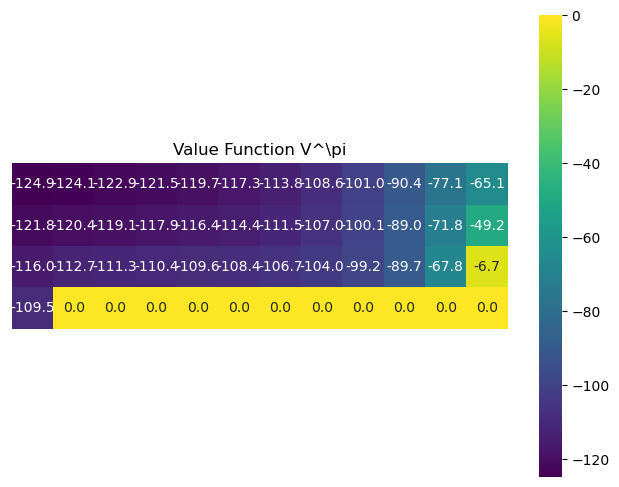

In [16]:
gamma = 1.0

# Choose any policy (a uniform random one)
pi = np.ones((37,4)) # excluding terminal states
pi = pi / 4

# Construct r_\pi
R = np.zeros(37)
for state in range(37):
    agent_pos = get_position(state)
    R[state] = sum(
        pi[state, action] * get_reward(get_state(move_agent(agent_pos, action)))
        for action in range(4)
    )
    
# print(f"Reward vector R is:\n{R[0:36].reshape(4,-1)}")
# print(R[36])

# Construct P_pi
P = np.zeros((37,37))

for state in range(37):
    agent_pos = get_position(state)
    for action in range(4):
        state_next = get_state(move_agent(agent_pos,action))
        if state_next > 36:
            continue # Do not record transition to terminal states
        P[state, state_next] += pi[state, action]


    
# print(f"Transition matrix P_pi is:\n {P}")

# Compute V_pi by solving the linear equation. 
V = np.linalg.inv(np.identity(37) - gamma * P) @ R
V = np.concatenate((V, np.zeros(11))) # V=0 at terminal states
visualize_value_function(V, 'Value Function V^\pi')

## 4. Fitted Monte Carlo policy evaluation for $V^\pi$ for a given $\pi$

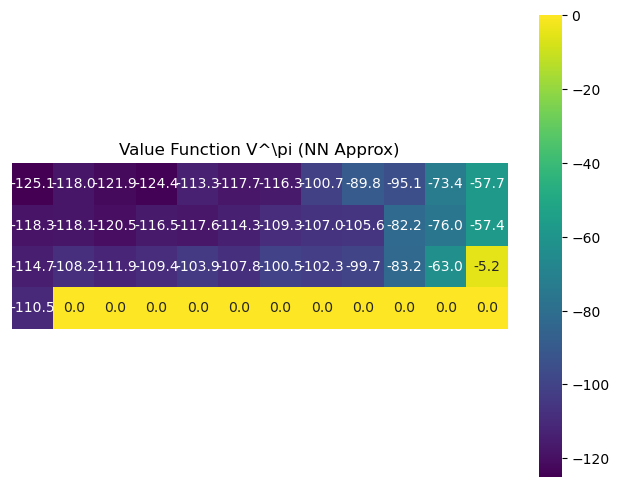

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import trange

class ValueNetwork(nn.Module):
    def __init__(self, input_dim=2, fourier_dim=32, hidden_dim=128):
        super().__init__()
        B = torch.randn(fourier_dim, input_dim) * 10  # Frequency matrix
        self.register_buffer('B', B) # B is not trained

        self.net = nn.Sequential(
            nn.Linear(2 * fourier_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def fourier_features(self, x):
        # x: (batch_size, 2)
        proj = 2 * np.pi * x @ self.B.T
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)

    def forward(self, x):  # x in R^2
        phi = self.fourier_features(x)
        return self.net(phi).squeeze(-1)


gamma = 1.0
N = 1024
batchsize = 64
learning_rate = 1e-3

Vnet = ValueNetwork() #V_\phi \approx V^\pi
optimizer = optim.Adam(Vnet.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()


for _ in range(N):
    batch = []
    for _ in range(batchsize):
        s0 = np.random.randint(37) # random starting state
        rewards = []
        agent_pos = get_position(s0)
        while True: #simulate full trajectory
            action = np.random.randint(4)
            agent_pos = move_agent(agent_pos, action)
            s = get_state(agent_pos)
            rewards.append(get_reward(s))
            if s == goal_state or s in cliff_states:
                break
        G = sum(gamma ** k * r for k, r in enumerate(rewards))
        x, y = get_position(s0)
        batch.append(((x / 3.0, y / 11.0), G))  # normalize (x,y) such that x/3\in [0,1] and y/11\in[0,1]
    xy = torch.tensor([pos for pos, _ in batch], dtype=torch.float32)
    G_vals = torch.tensor([G for _, G in batch], dtype=torch.float32)
    loss = loss_fn(Vnet(xy), G_vals)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Predict value for all 48 states
grid_input = torch.tensor([
    (x / 3.0, y / 11.0) for x in range(4) for y in range(12)
], dtype=torch.float32)

with torch.no_grad():
    predicted_V = Vnet(grid_input).numpy()
predicted_V[-11:] = 0 # Set terminal state values to 0

visualize_value_function(predicted_V, title="Value Function V^\pi (NN Approx)")

## 5. Fitted k-step TD policy evaluation for V

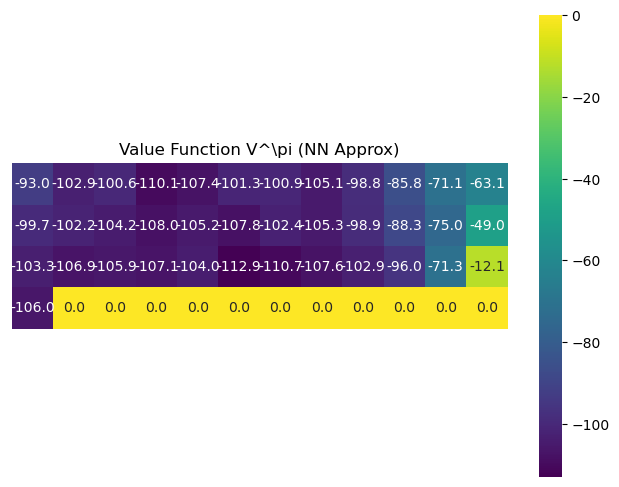

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import trange

class ValueNetwork(nn.Module):
    def __init__(self, input_dim=2, fourier_dim=32, hidden_dim=128):
        super().__init__()
        B = torch.randn(fourier_dim, input_dim) * 10  # Frequency matrix
        self.register_buffer('B', B) # B is not trained

        self.net = nn.Sequential(
            nn.Linear(2 * fourier_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def fourier_features(self, x):
        # x: (batch_size, 2)
        proj = 2 * np.pi * x @ self.B.T
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)

    def forward(self, x):  # x in R^2
        phi = self.fourier_features(x)
        return self.net(phi).squeeze(-1)


gamma = 1.0
k = 5
N = 1024
batchsize = 64
learning_rate = 1e-4

Vnet = ValueNetwork()
optimizer = optim.Adam(Vnet.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()


for kkk in range(N):
    batch = []
    for _ in range(batchsize):
        s0 = np.random.randint(37) # random starting state
        agent_pos = get_position(s0)
        G = 0
        hit_terminal = False
        for t in range(k):
            action = np.random.randint(4)
            agent_pos = move_agent(agent_pos, action)
            s = get_state(agent_pos)
            G += gamma**t * get_reward(s)
            if s == goal_state or s in cliff_states:
                hit_terminal = True
                break
        if not hit_terminal:
            x, y = get_position(s)
            last_pos = (x / 3.0, y / 11.0)  # normalize (x,y)
            G += gamma**k * Vnet(torch.tensor(last_pos)).detach() #stop gradient operator
        x, y = get_position(s0)
        init_pos = (x / 3.0, y / 11.0)  # normalize (x,y)
        batch.append((init_pos, G))
    xy = torch.tensor([pos for pos, _ in batch], dtype=torch.float32)
    G_vals = torch.tensor([G for _, G in batch], dtype=torch.float32)
    loss = loss_fn(Vnet(xy), G_vals)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Predict value for all 48 states
grid_input = torch.tensor([
    (x / 3.0, y / 11.0) for x in range(4) for y in range(12)
], dtype=torch.float32)

with torch.no_grad():
    predicted_V = Vnet(grid_input).numpy()
predicted_V[-11:] = 0 # Set terminal state values to 0

visualize_value_function(predicted_V, title="Value Function V^\pi (NN Approx)")

## 6. Policy gradient method (A2C)

100%|████████████████████████████████████| 10240/10240 [00:43<00:00, 237.10it/s]


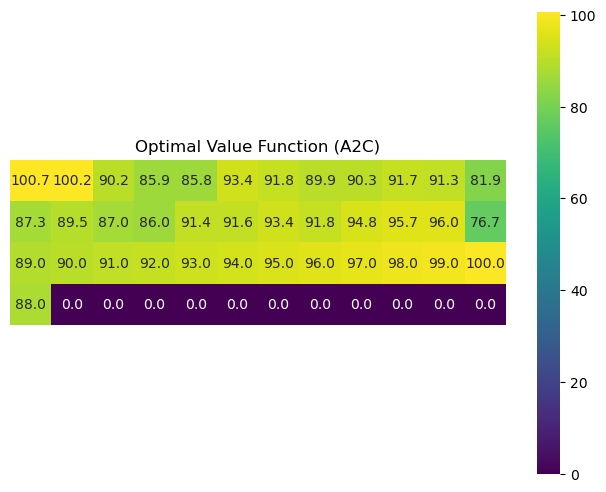

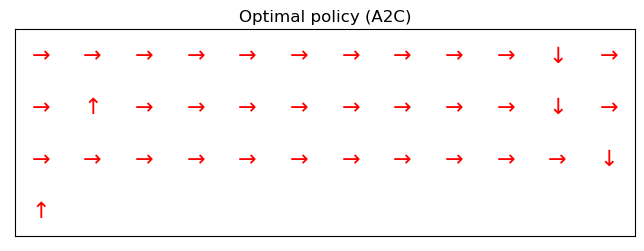

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tqdm import trange



class ValueNetwork(nn.Module):
    def __init__(self, input_dim=2, fourier_dim=32, hidden_dim=128):
        super().__init__()
        B = torch.randn(fourier_dim, input_dim) * 10  # Frequency matrix
        self.register_buffer('B', B) # B is not trained

        self.net = nn.Sequential(
            nn.Linear(2 * fourier_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def fourier_features(self, x):
        # x: (batch_size, 2)
        proj = 2 * np.pi * x @ self.B.T
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)

    def forward(self, x):  # x in R^2
        phi = self.fourier_features(x)
        return self.net(phi).squeeze(-1)

    
class PolicyNetwork(nn.Module):
    def __init__(self, input_dim=2, fourier_dim=32, hidden_dim=128, n_actions=4):
        super().__init__()
        B = torch.randn(fourier_dim, input_dim) * 10
        self.register_buffer('B', B)

        self.net = nn.Sequential(
            nn.Linear(2 * fourier_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_actions)
        )

    def fourier_features(self, x):
        proj = 2 * np.pi * x @ self.B.T
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)

    def forward(self, x):
        phi = self.fourier_features(x)
        logits = self.net(phi)
        return torch.softmax(logits, dim=-1)

# Initialize networks
Vnet = ValueNetwork()
Pnet = PolicyNetwork()

value_optimizer = optim.Adam(Vnet.parameters(), lr=3e-4)
policy_optimizer = optim.Adam(Pnet.parameters(), lr=3e-4)


gamma = 1.0
k = 5
N = 10240

s = goal_state
for _ in trange(N):
    if s == goal_state or s in cliff_states: # if at terminal
        s0 = 36  #  initial state
    else:
        s0 = s
    agent_pos = get_position(s0)

    hit_terminal = False
    dynamics = []
    for t in range(k):
        x0, y0 = agent_pos
        input_pos = torch.tensor([(x0 / 3.0, y0 / 11.0)], dtype=torch.float32)

        probs = Pnet(input_pos).squeeze(0)
        action = torch.multinomial(probs, 1).item()

        agent_pos = move_agent(agent_pos, action)
        s = get_state(agent_pos)
        
        reward = get_reward(s)

        dynamics.append( (input_pos,action,reward) )

        if s == goal_state or s in cliff_states:
            hit_terminal = True
            break

    loss_P, loss_V = torch.tensor(0.0), torch.tensor(0.0)
    Qhat = 0.0
    if not hit_terminal:
        x, y = get_position(s)
        last_pos = torch.tensor([(x / 3.0, y / 11.0)], dtype=torch.float32)
        Qhat = Vnet(last_pos).detach().item()        
    for (state,action,r) in reversed(dynamics):
        Qhat = r + gamma*Qhat
        loss_P += - torch.log(Pnet(state)[0,action]) * (Qhat-Vnet(state).detach().item())
#         loss_P += - torch.log(Pnet(state)[0,action]) * (Qhat)  #Try removing the baseline function
        loss_V += 0.5 * (Qhat - Vnet(state).squeeze(0))**2
        
    # Update policy network
    policy_optimizer.zero_grad()
    loss_P.backward()
    policy_optimizer.step()
    
    # Update value network
    value_optimizer.zero_grad()
    loss_V.backward()
    value_optimizer.step()


# Visualize optimal value function

# Predict value for all 48 states
grid_input = torch.tensor([
    (x / 3.0, y / 11.0) for x in range(4) for y in range(12)
], dtype=torch.float32)

with torch.no_grad():
    predicted_V = Vnet(grid_input).numpy()
predicted_V[-11:] = 0 # Set terminal state values to 0

visualize_value_function(predicted_V, title="Optimal Value Function (A2C)")


# Visualize optimal policy
with torch.no_grad():
    pi = torch.zeros((4, 48))
    for state in range(48):
        x, y = get_position(state)
        input_pos = torch.tensor([(x / 3.0, y / 11.0)], dtype=torch.float32)
        probs = Pnet(input_pos).squeeze(0)
        pi[:, state] = probs
visualize_policy(pi.numpy(), "Optimal policy (A2C)")


## 7. Proximal policy optimization (PPO)

100%|█████████████████████████████████████████| 128/128 [00:16<00:00,  7.91it/s]


Agent has seen +100 reward


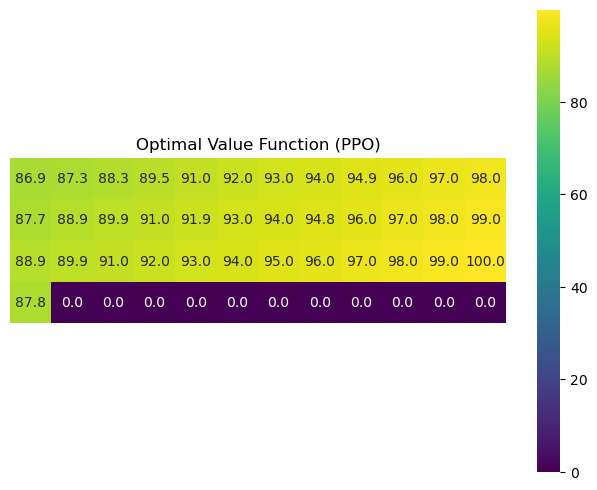

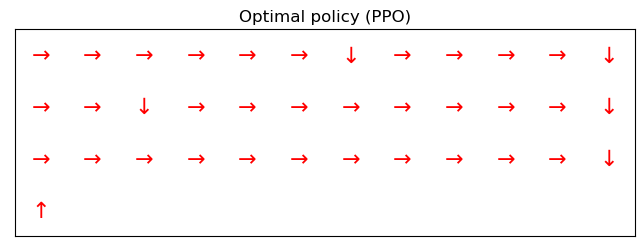

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tqdm import trange



class ValueNetwork(nn.Module):
    def __init__(self, input_dim=2, fourier_dim=32, hidden_dim=128):
        super().__init__()
        B = torch.randn(fourier_dim, input_dim) * 10  # Frequency matrix
        self.register_buffer('B', B) # B is not trained

        self.net = nn.Sequential(
            nn.Linear(2 * fourier_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def fourier_features(self, x):
        # x: (batch_size, 2)
        proj = 2 * np.pi * x @ self.B.T
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)

    def forward(self, x):  # x in R^2
        phi = self.fourier_features(x)
        return self.net(phi).squeeze(-1)

    
class PolicyNetwork(nn.Module):
    def __init__(self, input_dim=2, fourier_dim=32, hidden_dim=128, n_actions=4):
        super().__init__()
        B = torch.randn(fourier_dim, input_dim) * 10
        self.register_buffer('B', B)

        self.net = nn.Sequential(
            nn.Linear(2 * fourier_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_actions)
        )

    def fourier_features(self, x):
        proj = 2 * np.pi * x @ self.B.T
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)

    def forward(self, x):
        phi = self.fourier_features(x)
        logits = self.net(phi)
        return torch.softmax(logits, dim=-1)

# Initialize networks
Vnet = ValueNetwork()
Pnet = PolicyNetwork()

value_optimizer = optim.Adam(Vnet.parameters(), lr=1e-3)
policy_optimizer = optim.Adam(Pnet.parameters(), lr=1e-3)


gamma = 1.0
N = 128
clip_epsilon = 0.2
ppo_epochs = 4
trajectory_batch_size = 32
PPO_batch_size = 32

reward_flag = False

for _ in trange(N):
    trajectory_batch = []
    for _ in range(trajectory_batch_size):
        trajectory = []
        s0 = np.random.randint(37) # random starting state
#         s0 = 36  #  initial state

        agent_pos = get_position(s0)

        
        while True:
            x0, y0 = agent_pos
            input_pos = torch.tensor([(x0 / 3.0, y0 / 11.0)], dtype=torch.float32)

            probs = Pnet(input_pos).squeeze(0)
            action = torch.multinomial(probs, 1).item()

            agent_pos = move_agent(agent_pos, action)
            s = get_state(agent_pos)

            reward = get_reward(s)
            if reward==100:
                reward_flag = True

            #old probabilities
            prob_old = probs[action].detach()

            trajectory.append( (input_pos,action,prob_old,reward) )

            if s == goal_state or s in cliff_states:
                hit_terminal = True
                break


        # compute advantage for dynamics into (s,a,prob_old,Q,A)
        Qhat = 0.0
        dynamics_QA = []
        for ind,(state, action, prob_old, r) in enumerate(reversed(trajectory)):
            Qhat = r + gamma*Qhat
            dynamics_QA.append( (state, action, prob_old, Qhat, Qhat - Vnet(state).detach().item()) )
        trajectory_batch += dynamics_QA
    
    states = torch.cat([state for state,_,_,_,_ in trajectory_batch])
    actions = torch.tensor([action for _,action,_,_,_ in trajectory_batch])
    old_probs = torch.stack([pb for _,_,pb,_,_ in trajectory_batch])
    returns = torch.tensor([Q for _,_,_,Q,_ in trajectory_batch])
    advantages = torch.tensor([A for _,_,_,_,A in trajectory_batch])

    
    for _ in range(ppo_epochs):
        idx = torch.randperm(len(states))
        for i in range(0, len(states), PPO_batch_size):
            b_idx = idx[i:i+PPO_batch_size]
            b_states = states[b_idx]
            b_actions = actions[b_idx]
            b_old_probs = old_probs[b_idx]
            b_advantages = advantages[b_idx]
            b_returns = returns[b_idx]

            # Ratio
            ratio = Pnet(b_states)[range(len(b_states)), b_actions] / b_old_probs

            # Clipped surrogate objective
            surr1 = ratio * b_advantages
            surr2 = torch.clamp(ratio, 1 - clip_epsilon, 1 + clip_epsilon) * b_advantages
            policy_loss = -torch.min(surr1, surr2).mean()

            # Value function loss
            value_preds = Vnet(b_states).squeeze()
            value_loss = 0.5 * (b_returns - value_preds).pow(2).mean()

            # Optimize policy
            policy_optimizer.zero_grad()
            policy_loss.backward()
            policy_optimizer.step()

            # Optimize value function
            value_optimizer.zero_grad()
            value_loss.backward()
            value_optimizer.step()


            
if not reward_flag:
    print("Agent has never seen +100 reward")
else:
    print("Agent has seen +100 reward")
    
# Visualize optimal value function

# Predict value for all 48 states
grid_input = torch.tensor([
    (x / 3.0, y / 11.0) for x in range(4) for y in range(12)
], dtype=torch.float32)

with torch.no_grad():
    predicted_V = Vnet(grid_input).numpy()
predicted_V[-11:] = 0 # Set terminal state values to 0

visualize_value_function(predicted_V, title="Optimal Value Function (PPO)")


# Visualize optimal policy
with torch.no_grad():
    pi = torch.zeros((4, 48))
    for state in range(48):
        x, y = get_position(state)
        input_pos = torch.tensor([(x / 3.0, y / 11.0)], dtype=torch.float32)
        probs = Pnet(input_pos).squeeze(0)
        pi[:, state] = probs
visualize_policy(pi.numpy(), "Optimal policy (PPO)")
